# Confidence intervals — TES (Al), heavy mediator (F_DM = 1), m_DM = 100 MeV

Point-wise profile confidence bands of the recovered flux x(v_min), one
subsection per halo model. Method and conventions:
[`quantum_sensor.statistics.find_confidence_band`](../src/quantum_sensor/statistics.py)
(neutrinoAnalysis construction: observed profile Δχ² vs an MC-calibrated
cutoff; Poisson pseudo-experiments; CLARABEL solver, thread-parallel).

- Configuration: `material='Al', q='0', mass='2', nbins=5`, background `none`
- Outputs per model: `results/TES/bkg-none/<config>/` —
  `band/band_idx*.json` (primary, one per point), `flux_profile_band.csv`
  (summary), `flux_profile_band.pdf` (figure)
- **Each `run_model` cell takes ~30–60 min** (production MC settings).
  Already computed? Use `show_saved` in §Saved results instead.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sensor import (DarkMatterQuantumAnalysis, RunConfig,
                            pointwise_band, load_pointwise_band,
                            band_table, save_band_products)
from quantum_sensor.plotting import plot_flux_with_pointwise_bands, run_dir

MATERIAL, Q, MASS, NBINS = 'Al', '0', '2', 5
LEVELS = (0.68, 0.954)                                   # 1 sigma, 2 sigma
MC = dict(num_pseudo=50, n_pseudo_edge=500, rel_tol=0.02)  # production settings
N_INDICES = 30


def build(eta='Halo', disk_fraction=None):
    cfg = RunConfig(material=MATERIAL, q=Q, mass=MASS, nbins=NBINS,
                    eta=eta, disk_fraction=disk_fraction, background='none')
    a = DarkMatterQuantumAnalysis(cfg)
    a.optimize()
    return a


def run_model(eta='Halo', disk_fraction=None):
    """Compute, save and display the band for one halo model (heavy)."""
    a = build(eta, disk_fraction)
    print(f'{a.config}')
    print(f'counts per bin: {np.array2string(a.observed, precision=1)}')
    bands = pointwise_band(a, n_indices=N_INDICES, levels=LEVELS, **MC)
    save_band_products(a, bands)
    display(band_table(bands))
    return a, bands


def show_saved(eta='Halo', disk_fraction=None):
    """Reload a saved band (band/*.json) — no recomputation."""
    a = build(eta, disk_fraction)
    bands = load_pointwise_band(run_dir(a))
    print(f'{len(bands)} points from {run_dir(a) / "band"}')
    display(band_table(bands))
    plot_flux_with_pointwise_bands(a, bands, save=False)
    return a, bands


## 1. Standard halo (SHM)


RunConfig(material='Al', q='0', mass='2', nbins=5, eta='Halo', disk_fraction=None, background='none', run=None)
counts per bin: [ 75.  152.6 224.9 283.  337. ]
[1/4] idx 4 (v=24 km/s)  best 4.17e-27 cm^-1  1sigma [3.99e-27, 4.41e-27]  2sigma [3.84e-27, 5.07e-27]  (18 evals)
[2/4] idx 15 (v=33 km/s)  best 4.15e-27 cm^-1  1sigma [3.97e-27, 4.34e-27]  2sigma [3.83e-27, 4.75e-27]  (18 evals)
[3/4] idx 25 (v=41 km/s)  best 4.13e-27 cm^-1  1sigma [3.95e-27, 4.37e-27]  2sigma [3.81e-27, 4.72e-27]  (18 evals)
[4/4] idx 41 (v=53 km/s)  best 4.11e-27 cm^-1  1sigma [3.93e-27, 4.29e-27]  2sigma [3.73e-27, 4.46e-27]  (17 evals)
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux_profile_band.pdf
saved: flux_profile_band.csv / 4 json under band/ / pdf  (/Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo)


,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,4,23.8,4.168793e-27,3.988036e-27,4.413487e-27,3.839286e-27,5.073565e-27,-4%,+6%,18
1,15,32.6,4.153824e-27,3.973716e-27,4.342270e-27,3.825501e-27,4.745006e-27,-4%,+5%,18
2,25,40.6,4.132047e-27,3.952883e-27,4.374584e-27,3.805445e-27,4.720129e-27,-4%,+6%,18
3,41,53.3,4.105756e-27,3.927732e-27,4.292021e-27,3.733623e-27,4.458311e-27,-4%,+5%,17


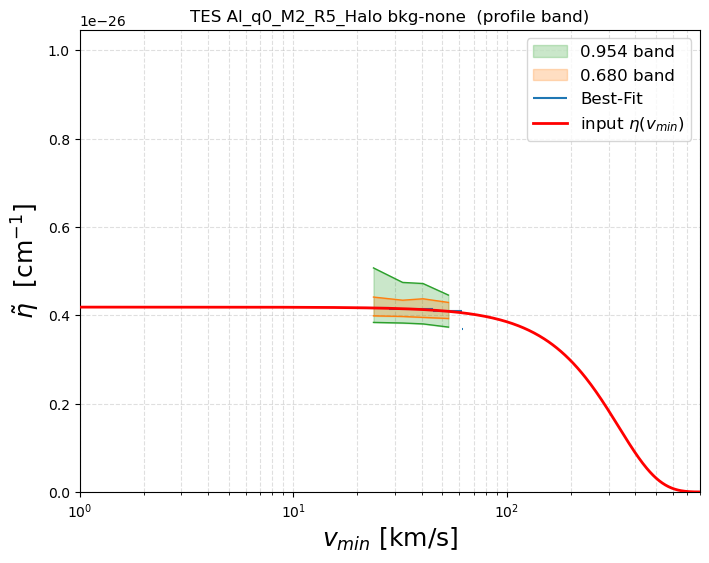

In [2]:
a_halo, b_halo = run_model(eta='Halo')


## 2. Pure dark disk


In [ ]:
a_disk, b_disk = run_model(eta='Disk')


## 3. Halo + dark-disk mixtures

The fit eta is `(1-p)·Halo + p·Disk` with the same total local DM density.


RunConfig(material='Al', q='0', mass='2', nbins=5, eta='Halo', disk_fraction=0.05, background='none', run=None)
counts per bin: [179.6 358.  523.7 694.5 842.7]
[1/22] idx 0 (v=13 km/s)  best 4.53e-27 cm^-1  1sigma [4.33e-27, 8.28e-26]  2sigma [4.28e-27, 1.89e-25]  (32 evals)
[2/22] idx 1 (v=14 km/s)  best 4.53e-27 cm^-1  1sigma [4.33e-27, 1.67e-26]  2sigma [4.22e-27, 3.2e-26]  (26 evals)
[3/22] idx 2 (v=15 km/s)  best 4.53e-27 cm^-1  1sigma [4.33e-27, 8.89e-27]  2sigma [4.22e-27, 1.43e-26]  (22 evals)
[4/22] idx 3 (v=16 km/s)  best 4.53e-27 cm^-1  1sigma [4.33e-27, 7.21e-27]  2sigma [4.22e-27, 1.1e-26]  (23 evals)
[5/22] idx 4 (v=17 km/s)  best 4.53e-27 cm^-1  1sigma [4.33e-27, 6.18e-27]  2sigma [4.22e-27, 8.81e-27]  (21 evals)
[6/22] idx 5 (v=17 km/s)  best 4.53e-27 cm^-1  1sigma [4.33e-27, 5.8e-27]  2sigma [4.22e-27, 7.66e-27]  (21 evals)
[7/22] idx 6 (v=18 km/s)  best 4.53e-27 cm^-1  1sigma [4.33e-27, 5.44e-27]  2sigma [4.22e-27, 6.66e-27]  (19 evals)
[8/22] idx 7 (v=19 km/s)  best 

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,13.4,4.527294e-27,4.330993e-27,8.280737e-26,4.276462e-27,1.886924e-25,-4%,+1729%,32
1,1,14.2,4.527294e-27,4.330993e-27,1.672376e-26,4.222618e-27,3.201512e-26,-4%,+269%,26
2,2,15.0,4.527294e-27,4.330993e-27,8.889661e-27,4.222618e-27,1.429691e-26,-4%,+96%,22
3,3,15.8,4.527294e-27,4.330993e-27,7.212538e-27,4.222618e-27,1.095676e-26,-4%,+59%,23
4,4,16.6,4.527294e-27,4.330993e-27,6.175432e-27,4.222618e-27,8.805361e-27,-4%,+36%,21
5,5,17.4,4.527294e-27,4.330993e-27,5.796329e-27,4.222618e-27,7.659771e-27,-4%,+28%,21
6,6,18.2,4.527294e-27,4.330993e-27,5.440500e-27,4.222618e-27,6.663224e-27,-4%,+20%,19
7,7,19.0,4.527294e-27,4.330993e-27,5.171629e-27,4.222618e-27,6.175432e-27,-4%,+14%,19
8,9,20.6,4.527294e-27,4.330993e-27,4.978733e-27,4.222618e-27,5.723349e-27,-4%,+10%,19
9,10,21.4,4.527294e-27,4.330993e-27,4.854149e-27,4.222618e-27,5.509874e-27,-4%,+7%,18


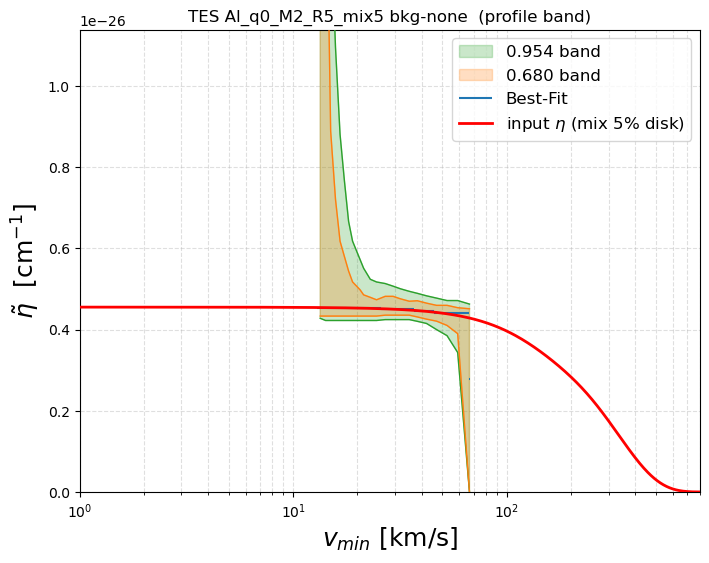

In [3]:
a_mix5, b_mix5 = run_model(disk_fraction=0.05)    # 5% disk


RunConfig(material='Al', q='0', mass='2', nbins=5, eta='Halo', disk_fraction=0.25, background='none', run=None)
counts per bin: [ 236.2  467.2  677.4  888.3 1064.2]
[1/22] idx 0 (v=13 km/s)  best 5.95e-27 cm^-1  1sigma [5.69e-27, 1.07e-25]  2sigma [5.48e-27, 2.48e-25]  (32 evals)
[2/22] idx 1 (v=14 km/s)  best 5.95e-27 cm^-1  1sigma [5.69e-27, 2.16e-26]  2sigma [5.48e-27, 4.14e-26]  (26 evals)
[3/22] idx 2 (v=15 km/s)  best 5.95e-27 cm^-1  1sigma [5.69e-27, 1.15e-26]  2sigma [5.48e-27, 1.84e-26]  (22 evals)
[4/22] idx 3 (v=16 km/s)  best 5.95e-27 cm^-1  1sigma [5.69e-27, 9.3e-27]  2sigma [5.48e-27, 1.39e-26]  (23 evals)
[5/22] idx 4 (v=17 km/s)  best 5.95e-27 cm^-1  1sigma [5.69e-27, 8.22e-27]  2sigma [5.48e-27, 1.13e-26]  (21 evals)
[6/22] idx 5 (v=17 km/s)  best 5.95e-27 cm^-1  1sigma [5.69e-27, 7.62e-27]  2sigma [5.48e-27, 1.01e-26]  (21 evals)
[7/22] idx 6 (v=18 km/s)  best 5.95e-27 cm^-1  1sigma [5.69e-27, 7.06e-27]  2sigma [5.48e-27, 8.76e-27]  (19 evals)
[8/22] idx 7 (v=19 km/s)

,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,13.4,5.951687e-27,5.693625e-27,1.071499e-25,5.481259e-27,2.480594e-25,-4%,+1700%,32
1,1,14.2,5.951687e-27,5.693625e-27,2.163998e-26,5.481259e-27,4.142647e-26,-4%,+264%,26
2,2,15.0,5.951687e-27,5.693625e-27,1.146654e-26,5.481259e-27,1.844120e-26,-4%,+93%,22
3,3,15.8,5.951687e-27,5.693625e-27,9.303262e-27,5.481259e-27,1.386676e-26,-4%,+56%,23
4,4,16.6,5.951687e-27,5.693625e-27,8.221888e-27,5.481259e-27,1.128607e-26,-4%,+38%,21
5,5,17.4,5.951687e-27,5.693625e-27,7.619991e-27,5.481259e-27,1.006971e-26,-4%,+28%,21
6,6,18.2,5.951687e-27,5.693625e-27,7.062156e-27,5.481259e-27,8.759631e-27,-4%,+19%,19
7,7,19.0,5.951687e-27,5.693625e-27,6.885439e-27,5.481259e-27,8.016150e-27,-4%,+16%,19
8,9,20.6,5.951687e-27,5.693625e-27,6.462750e-27,5.481259e-27,7.429314e-27,-4%,+9%,19
9,10,21.4,5.951687e-27,5.693625e-27,6.381379e-27,5.481259e-27,7.152209e-27,-4%,+7%,18


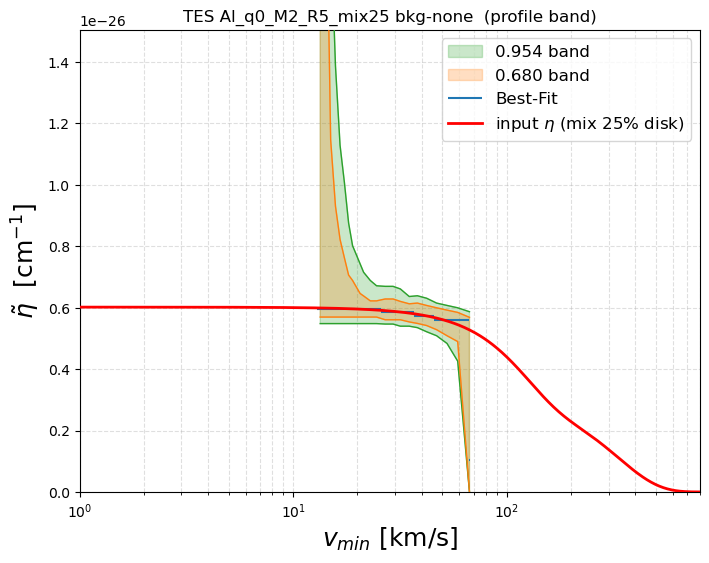

In [4]:
a_mix25, b_mix25 = run_model(disk_fraction=0.25)  # 25% disk


## Saved results (no recomputation)

Reload any model computed above (or in a previous session).


26 points from /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/band


,index,vmin [km/s],best fit [cm^-1],lo 1sigma [cm^-1],hi 1sigma [cm^-1],lo 2sigma [cm^-1],hi 2sigma [cm^-1],-68%,+68%,evals
0,0,13.4,4.171196e-27,4.041217e-27,7.629408e-26,3.940093e-27,1.942344e-25,-3%,+1729%,32
1,1,14.2,4.171196e-27,4.041217e-27,1.469333e-26,3.940093e-27,2.949694e-26,-3%,+252%,26
2,2,15.0,4.171196e-27,4.041217e-27,8.190437e-27,3.940093e-27,1.342512e-26,-3%,+96%,22
3,3,15.8,4.171196e-27,4.041217e-27,6.520122e-27,3.940093e-27,1.009495e-26,-3%,+56%,23
4,4,16.6,4.171196e-27,4.041217e-27,5.835726e-27,3.940093e-27,7.810170e-27,-3%,+40%,21
5,5,17.4,4.171196e-27,4.041217e-27,5.340414e-27,3.940093e-27,6.880690e-27,-3%,+28%,21
6,6,18.2,4.171196e-27,4.041217e-27,5.012573e-27,3.940093e-27,6.217405e-27,-3%,+20%,19
7,7,19.0,4.171196e-27,4.041217e-27,4.825609e-27,3.940093e-27,5.835726e-27,-3%,+16%,19
8,8,19.8,4.171196e-27,4.041217e-27,4.645619e-27,3.940093e-27,5.547323e-27,-3%,+11%,19
9,9,20.6,4.171196e-27,4.041217e-27,4.529371e-27,3.940093e-27,5.408512e-27,-3%,+9%,19


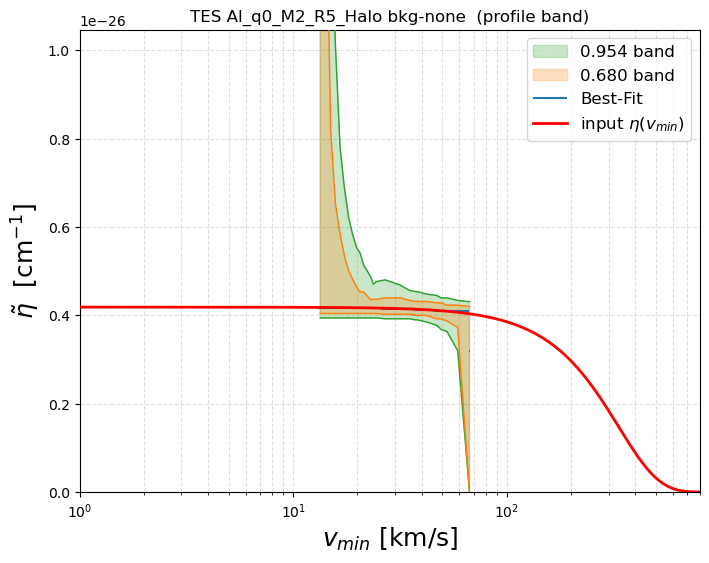

In [5]:
show_saved(eta='Halo');
# show_saved(eta='Disk');
# show_saved(disk_fraction=0.05);
# show_saved(disk_fraction=0.25);
